Q-Learning 

In [15]:
# Re-import after execution reset
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import random

In [16]:
# Environment setup
grid_size = (4, 4)
terminal_states = [(0, 0), (3, 3)]
rewards = -0.1 * np.ones(grid_size)
rewards[0, 0] = 1.0
rewards[3, 3] = 1.0
actions = ['U', 'D', 'L', 'R']
action_to_delta = {'U': (-1, 0), 'D': (1, 0), 'L': (0, -1), 'R': (0, 1)}
gamma = 0.9
episodes = 100

In [17]:
# Helper function: Get next state
def get_next_state(state, action):
    delta = action_to_delta[action]
    next_state = (state[0] + delta[0], state[1] + delta[1])
    if 0 <= next_state[0] < grid_size[0] and 0 <= next_state[1] < grid_size[1]:
        return next_state
    return state  # wall bounce

# Epsilon-greedy policy
def choose_action(state, Q, epsilon=0.1):
    if random.random() < epsilon:
        return random.choice(actions)
    else:
        i, j = state
        return actions[np.argmax(Q[i, j])]

# Monte Carlo First-Visit for Q(s,a)
def monte_carlo_q_learning():
    Q = np.zeros(grid_size + (len(actions),))
    returns = [[[] for _ in range(grid_size[1])] for _ in range(grid_size[0])]
    visit_counts = np.zeros_like(Q)
    snapshots = []

    for ep in range(1, episodes + 1):
        # Generate episode
        episode = []
        state = (random.randint(0, 3), random.randint(0, 3))
        while state in terminal_states:
            state = (random.randint(0, 3), random.randint(0, 3))

        done = False
        trajectory = []

        while not done:
            action = choose_action(state, Q, epsilon=0.1)
            next_state = get_next_state(state, action)
            reward = rewards[next_state]
            trajectory.append((state, action, reward))
            if next_state in terminal_states:
                done = True
            state = next_state

        # Calculate returns and update Q
        G = 0
        visited = set()
        for t in reversed(range(len(trajectory))):
            s, a, r = trajectory[t]
            G = gamma * G + r
            a_idx = actions.index(a)
            if (s, a) not in visited:  # First-visit check
                returns[s[0]][s[1]].append(G)
                Q[s[0], s[1], a_idx] = np.mean(returns[s[0]][s[1]])
                visited.add((s, a))

        if ep % 500 == 0:
            snapshots.append(np.max(Q, axis=2).copy())

    policy = np.full(grid_size, '', dtype=object)
    for i in range(grid_size[0]):
        for j in range(grid_size[1]):
            if (i, j) in terminal_states:
                policy[i, j] = 'T'
            else:
                best_action = actions[np.argmax(Q[i, j])]
                policy[i, j] = best_action
    return Q, policy, snapshots

In [18]:
# Plotting
def plot_policy_and_value(Q, policy, title):
    V = np.max(Q, axis=-1)
    fig, ax = plt.subplots(figsize=(6, 6))
    for i in range(grid_size[0]):
        for j in range(grid_size[1]):
            ax.add_patch(patches.Rectangle((j, grid_size[0]-1-i), 1, 1, fill=False))
            ax.text(j + 0.5, grid_size[0]-1-i + 0.6, f"{V[i, j]:.2f}", ha='center', fontsize=8)
            ax.text(j + 0.5, grid_size[0]-1-i + 0.25, policy[i, j], ha='center', fontsize=12, fontweight='bold')
    ax.set_xlim(0, grid_size[1])
    ax.set_ylim(0, grid_size[0])
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(title)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def plot_learning_snapshots(snapshots, title_prefix):
    for i, V in enumerate(snapshots):
        fig, ax = plt.subplots()
        c = ax.imshow(V, cmap='coolwarm', origin='upper')
        ax.set_title(f"{title_prefix} - Episode {(i+1)*500}")
        fig.colorbar(c)
        plt.show()

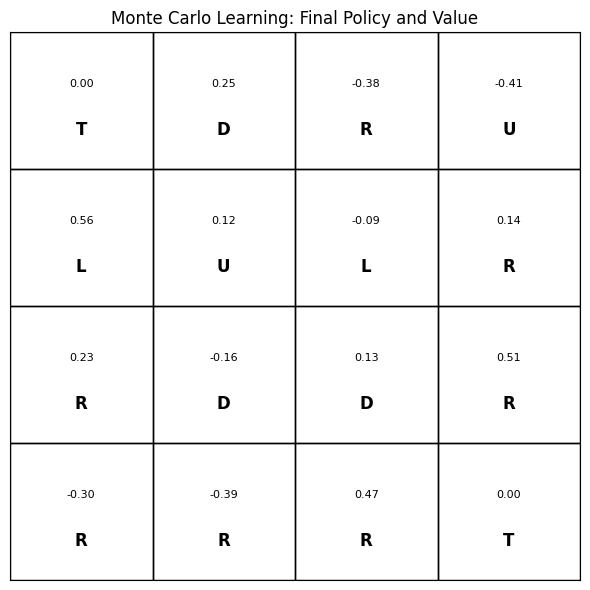

In [19]:
# Run the MC learning
Q_mc, policy_mc, snapshots_mc = monte_carlo_q_learning()
plot_policy_and_value(Q_mc, policy_mc, "Monte Carlo Learning: Final Policy and Value")
plot_learning_snapshots(snapshots_mc, "Monte Carlo Value Progress")

Value Updates

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import random

In [22]:
# Environment configuration
grid_size = (4, 4)
terminal_states = [(0, 0), (3, 3)]
rewards = -0.1 * np.ones(grid_size)
rewards[0, 0] = 1.0
rewards[3, 3] = 1.0
gamma = 0.9
episodes = 100
actions = ['U', 'D', 'L', 'R']
action_to_delta = {'U': (-1, 0), 'D': (1, 0), 'L': (0, -1), 'R': (0, 1)}

In [26]:
# Get next state based on action
def get_next_state(state, action):
    delta = action_to_delta[action]
    next_state = (state[0] + delta[0], state[1] + delta[1])
    if 0 <= next_state[0] < grid_size[0] and 0 <= next_state[1] < grid_size[1]:
        return next_state
    return state

# Random policy
def choose_action():
    return random.choice(actions)

# Monte Carlo First-Visit Value Estimation
def monte_carlo_value_estimation():
    V = np.zeros(grid_size) # initial value matrix to all zeroes
    # A 2D list of lists that stores all observed returns Gt for each state
    # Each call returns[i][j] corresponds to a state (i, j) in the GridWorld
    returns = [[[] for _ in range(grid_size[1])] for _ in range(grid_size[0])] 
    snapshots = [] # store value function snapshots every few episodes

    for ep in range(1, episodes + 1):
        # Pick a random starting state, avoiding terminal ones
        state = (random.randint(0, 3), random.randint(0, 3))
        while state in terminal_states:
            state = (random.randint(0, 3), random.randint(0, 3))

        trajectory = []
        done = False

        while not done:
            action = choose_action()
            next_state = get_next_state(state, action)
            reward = rewards[next_state]
            trajectory.append((state, reward))
            if next_state in terminal_states:
                done = True
            state = next_state

        # Calculate return and update values
        G = 0 # total discounted reward going backward
        visited = set() # keeps track of the states we’ve already updated this episode
        for t in reversed(range(len(trajectory))):
            s, r = trajectory[t]
            G = gamma * G + r
            if s not in visited:
                returns[s[0]][s[1]].append(G)
                V[s[0], s[1]] = np.mean(returns[s[0]][s[1]])
                visited.add(s)

        if ep % 20 == 0:
            snapshots.append(V.copy())

    return V, snapshots

In [27]:
# Plotting value function
def plot_value_function(V, title):
    fig, ax = plt.subplots(figsize=(6, 6))
    for i in range(grid_size[0]):
        for j in range(grid_size[1]):
            ax.add_patch(patches.Rectangle((j, grid_size[0]-1-i), 1, 1, fill=False))
            ax.text(j + 0.5, grid_size[0]-1-i + 0.4, f"{V[i, j]:.2f}", ha='center', fontsize=10)
    ax.set_xlim(0, grid_size[1])
    ax.set_ylim(0, grid_size[0])
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(title)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Plot snapshots of learning progress
def plot_value_snapshots(snapshots, title_prefix):
    for i, V in enumerate(snapshots):
        fig, ax = plt.subplots()
        c = ax.imshow(V, cmap='coolwarm', origin='upper')
        ax.set_title(f"{title_prefix} - Episode {(i+1)*500}")
        fig.colorbar(c)
        plt.show()

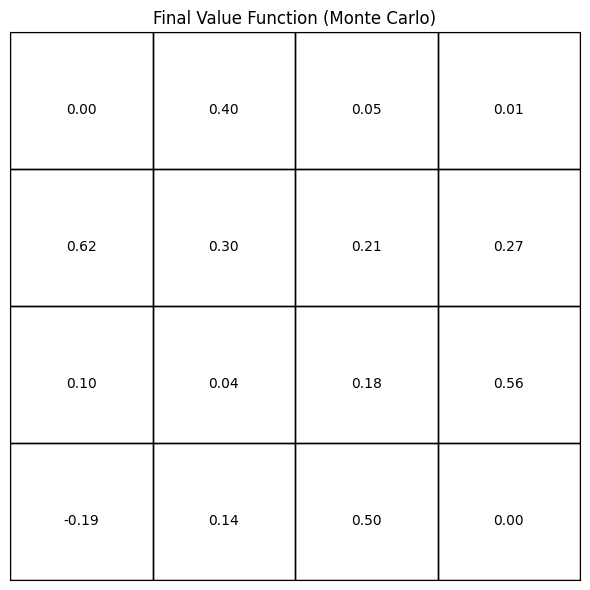

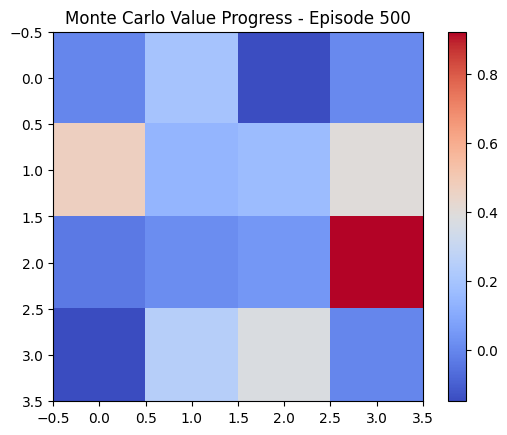

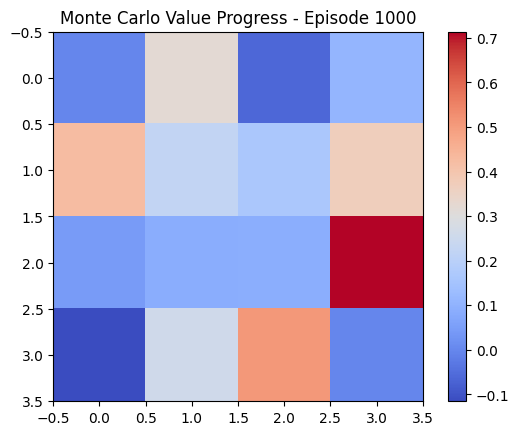

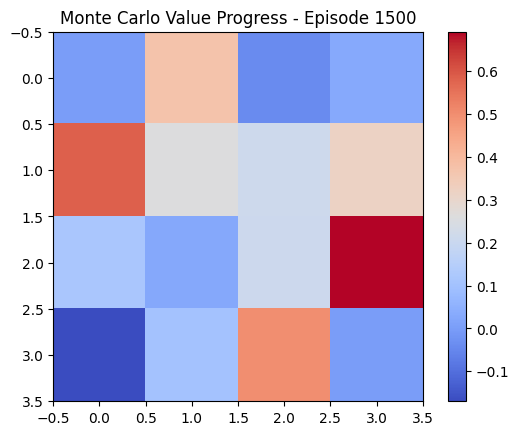

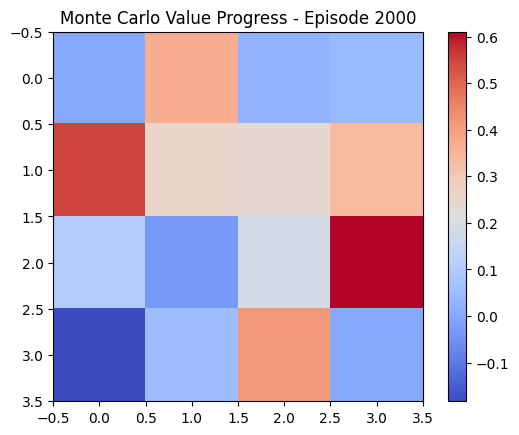

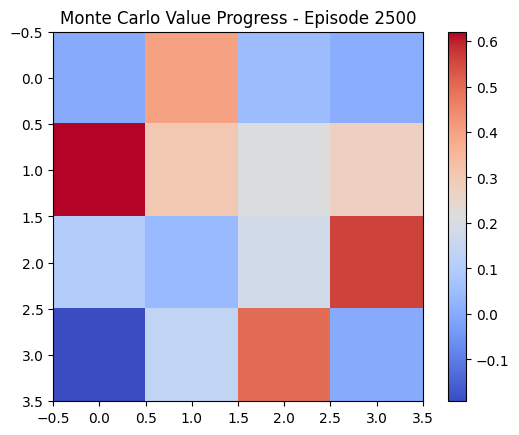

In [28]:
# Run the Monte Carlo value estimator
V_mc, snapshots_mc = monte_carlo_value_estimation()
plot_value_function(V_mc, "Final Value Function (Monte Carlo)")
plot_value_snapshots(snapshots_mc, "Monte Carlo Value Progress")